# Lab 5 - Grover's Algorithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel, pauli_error

## TODO 1 - Oracle

We need to create a function that marks the states we want to find. The idea is to flip the phase of the target states by -1. To do this we apply X gates where the state has a 0, wich transforms the state into |11...1>, then we use a multi-controlled phase gate to flip the phase, and then we undo the X gates.

In [2]:
def gen_oracle(qc, state_list):
    n = qc.num_qubits
    
    for state in state_list:
        # we need to reverse because in qiskit qubit 0 is the least significant
        rev = state[::-1]
        
        # put X gates where there is a 0
        for i in range(len(rev)):
            if rev[i] == '0':
                qc.x(i)
        
        # multi controlled phase to flip |11...1>
        ctrl = []
        for i in range(n-1):
            ctrl.append(i)
        qc.mcp(np.pi, ctrl, n-1)
        
        # undo the X gates
        for i in range(len(rev)):
            if rev[i] == '0':
                qc.x(i)
    
    return qc

## TODO 2 - Diffusion operator

The diffusion operator is always the same : H - X - multi controlled Z - X - H. It does a reflexion around the mean of the amplitudes.

In [3]:
def gen_diffusion(qc):
    n = qc.num_qubits
    
    # apply H on all qubits
    for i in range(n):
        qc.h(i)
    
    # apply X on all qubits
    for i in range(n):
        qc.x(i)
    
    # multi controlled Z
    ctrl = []
    for i in range(n-1):
        ctrl.append(i)
    qc.mcp(np.pi, ctrl, n-1)
    
    # undo X
    for i in range(n):
        qc.x(i)
    
    # undo H
    for i in range(n):
        qc.h(i)
    
    return qc

## TODO 3 - Ideal simulation

Function to simulate the circuit whitout noise using Aer.

In [4]:
def ideal_sim(qc, shots=2048):
    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts

Testing with 5 qubits and 1 grover iteration. We mark the state 10101.

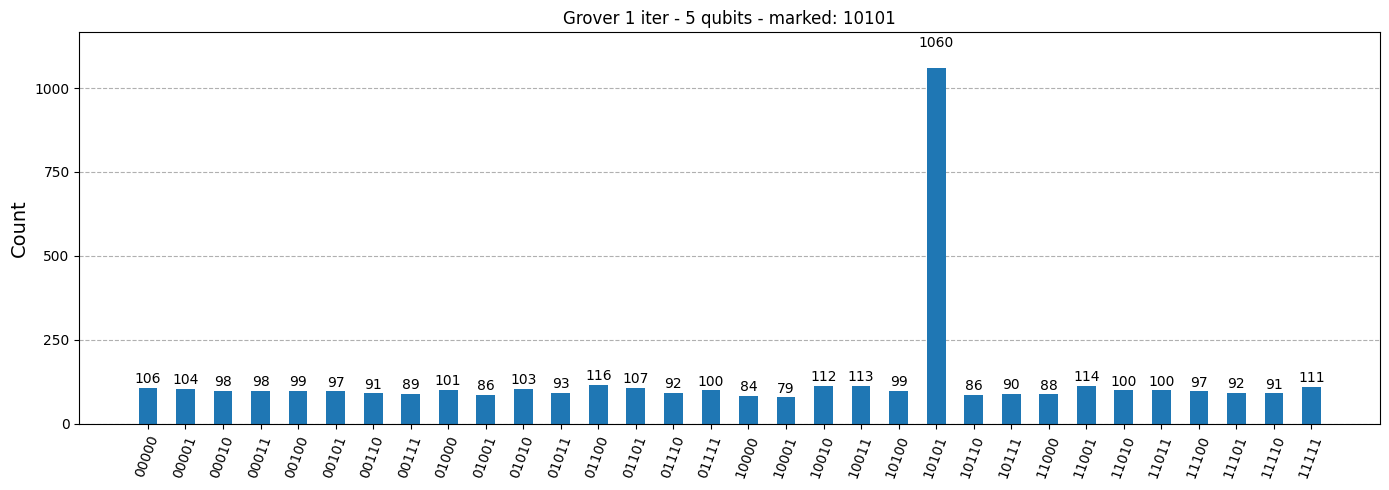

In [5]:
n = 5
qc_test = QuantumCircuit(n, n)

# hadamard on all qubits for superposition
for i in range(n):
    qc_test.h(i)

# one grover iteration
gen_oracle(qc_test, ['10101'])
gen_diffusion(qc_test)

# measure
for i in range(n):
    qc_test.measure(i, i)

counts = ideal_sim(qc_test, shots=4096)
plot_histogram(counts, figsize=(14, 5), title='Grover 1 iter - 5 qubits - marked: 10101')

We can see that 10101 has a higher probability then the other states wich is expected.

## TODO 4 - Plot amplitudes

Function to plot the amplitudes of the statevector. The circuit should not have mesurements.

In [6]:
def plot_amplitudes(qc):
    sv = Statevector.from_instruction(qc)
    n = qc.num_qubits
    N = 2**n
    
    amps = []
    labels = []
    for i in range(N):
        amps.append(sv.data[i].real)
        labels.append(format(i, '0' + str(n) + 'b'))
    
    plt.figure(figsize=(max(10, N*0.4), 5))
    plt.bar(labels, amps)
    plt.xlabel('Basis states')
    plt.ylabel('Amplitude')
    plt.title('Quantum State Amplitudes (Real Part)')
    if N > 16:
        plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    return amps

3 qubits, marked state 110:


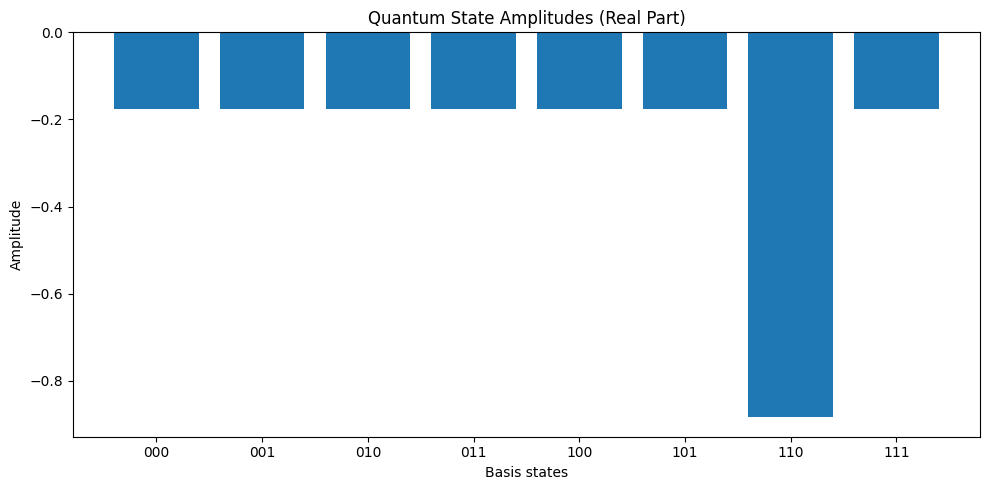

In [7]:
# test with 3 qubits marking 110
qc1 = QuantumCircuit(3)
qc1.h(0)
qc1.h(1)
qc1.h(2)
gen_oracle(qc1, ['110'])
gen_diffusion(qc1)

print("3 qubits, marked state 110:")
a = plot_amplitudes(qc1)

4 qubits, marked states 0011 and 1100:


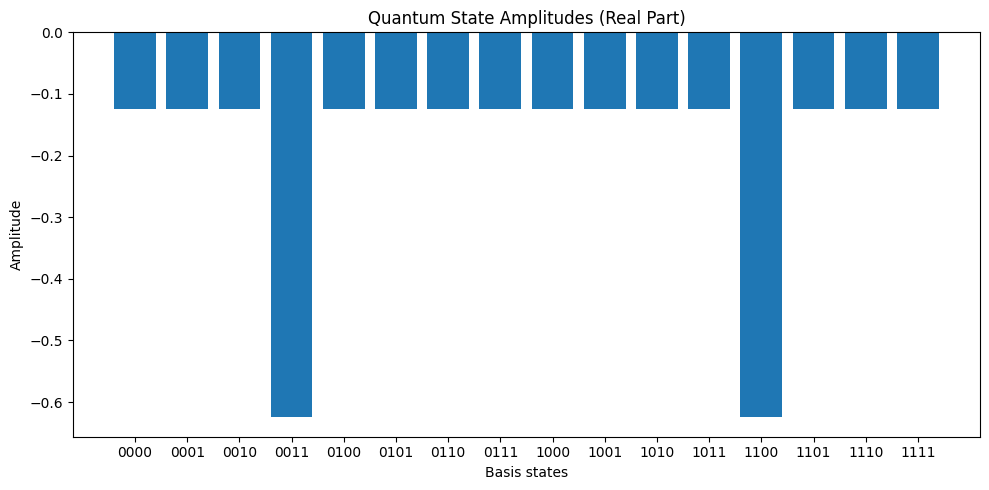

In [8]:
# test with 4 qubits marking 0011 and 1100
qc2 = QuantumCircuit(4)
qc2.h(0)
qc2.h(1)
qc2.h(2)
qc2.h(3)
gen_oracle(qc2, ['0011', '1100'])
gen_diffusion(qc2)

print("4 qubits, marked states 0011 and 1100:")
a2 = plot_amplitudes(qc2)

2 qubits, marked state 00:


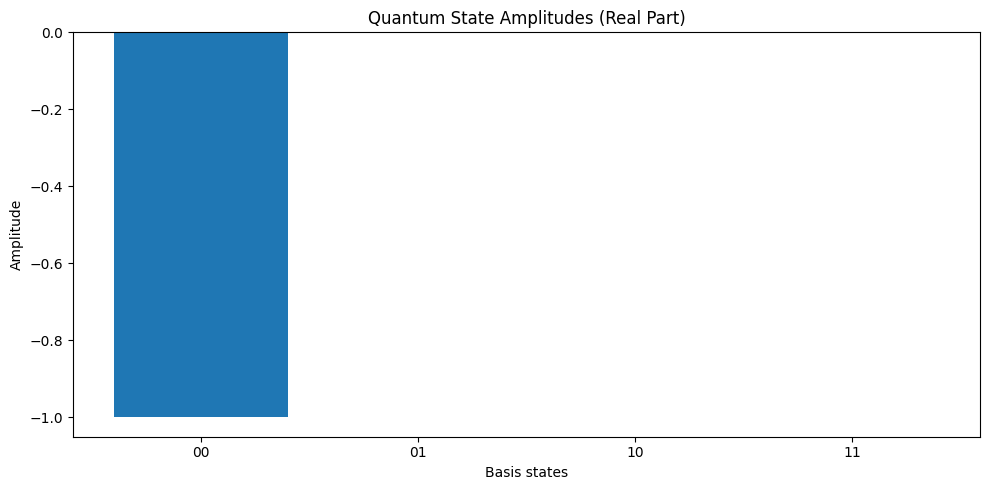

In [9]:
# test with 2 qubits marking 00
qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.h(1)
gen_oracle(qc3, ['00'])
gen_diffusion(qc3)

print("2 qubits, marked state 00:")
a3 = plot_amplitudes(qc3)

The oracle works for different number of qubits and different lists of states to mark. The marked states always have a higher amplitude after 1 iteration.

## TODO 5 - Grover 4 qubits, 1 searched state

We look at how the amplitude of the marked state changes with the number of iterations.

In [10]:
n_qubits = 4
N = 2**n_qubits  # 16
target = ['1010']
target_idx = int(target[0], 2)  # = 10

# optimal number of iterations is about pi/4 * sqrt(N) = pi/4 * 4 ~ 3.14
print(f"Marked state: {target[0]} (index {target_idx})")
print(f"N = {N}, optimal iters ~ {np.pi/4 * np.sqrt(N):.2f}")

max_iter = 12
amps_list = []

for it in range(1, max_iter+1):
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    
    for k in range(it):
        gen_oracle(qc, target)
        gen_diffusion(qc)
    
    sv = Statevector.from_instruction(qc)
    amp = sv.data[target_idx].real
    amps_list.append(amp)
    prob = amp * amp  # probability is amplitude squared
    print(f"Iter {it:2d}: amp = {amp:.6f}, prob = {prob:.6f}")

Marked state: 1010 (index 10)
N = 16, optimal iters ~ 3.14
Iter  1: amp = -0.687500, prob = 0.472656
Iter  2: amp = 0.953125, prob = 0.908447
Iter  3: amp = -0.980469, prob = 0.961319
Iter  4: amp = 0.762695, prob = 0.581704


Iter  5: amp = -0.354248, prob = 0.125492
Iter  6: amp = -0.142761, prob = 0.020381
Iter  7: amp = 0.604080, prob = 0.364913
Iter  8: amp = -0.914379, prob = 0.836089
Iter  9: amp = 0.996083, prob = 0.992182


Iter 10: amp = -0.828767, prob = 0.686854
Iter 11: amp = 0.454258, prob = 0.206351


Iter 12: amp = 0.033815, prob = 0.001143


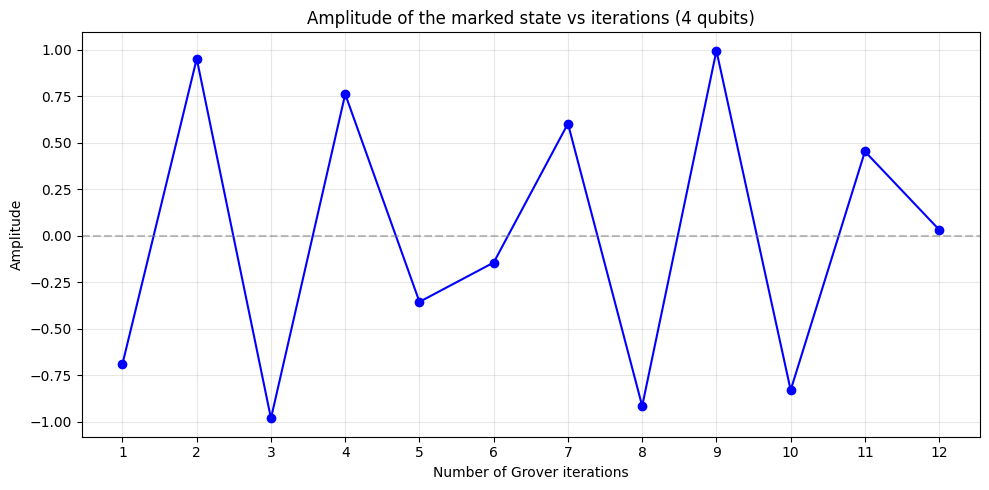

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_iter+1), amps_list, 'bo-')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Number of Grover iterations')
plt.ylabel('Amplitude')
plt.title('Amplitude of the marked state vs iterations (4 qubits)')
plt.xticks(range(1, max_iter+1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

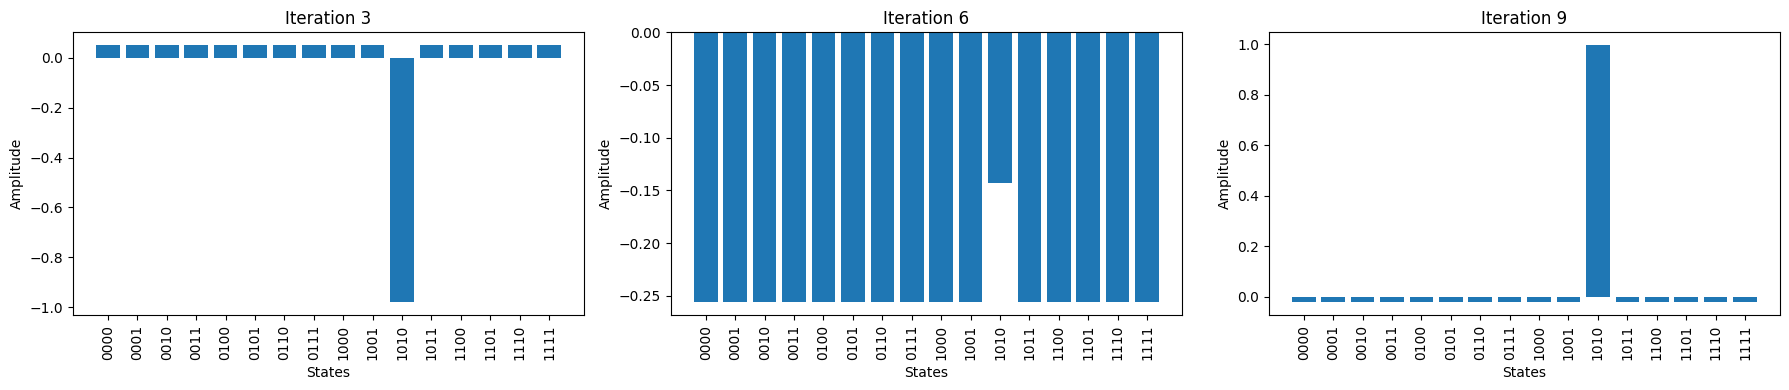

In [12]:
# plotting amplitudes at iteration 3, 6 and 9 to see the evolution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

iters_show = [3, 6, 9]
for j in range(3):
    it = iters_show[j]
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    for k in range(it):
        gen_oracle(qc, target)
        gen_diffusion(qc)
    
    sv = Statevector.from_instruction(qc)
    amps = []
    lbls = []
    for i in range(N):
        amps.append(sv.data[i].real)
        lbls.append(format(i, '04b'))
    
    axes[j].bar(lbls, amps)
    axes[j].set_title(f'Iteration {it}')
    axes[j].set_xlabel('States')
    axes[j].set_ylabel('Amplitude')
    axes[j].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The amplitude is maximal around iteration 3 wich matches the theoritical value of pi/4 * sqrt(16) ~ 3.14. After that the amplitude starts to decrease because grover's algorithm is basicly a rotation and if we go too far we pass the optimal point. So the amplitude starts to **diminish at around iteration 3-4**.

## TODO 6 - Grover 4 qubits, 2 searched states

Same thing but with 2 marked states this time.

In [13]:
n_qubits = 4
N = 2**n_qubits
targets2 = ['1010', '0101']

target_idxs = []
for s in targets2:
    target_idxs.append(int(s, 2))
print(f"Marked: {targets2} (indices {target_idxs})")
print(f"Optimal iters ~ pi/4 * sqrt(N/M) = {np.pi/4 * np.sqrt(N/2):.2f}")

max_iter = 12
amps_list2 = []

for it in range(1, max_iter+1):
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    
    for k in range(it):
        gen_oracle(qc, targets2)
        gen_diffusion(qc)
    
    sv = Statevector.from_instruction(qc)
    # compute average amplitude of the 2 marked states
    total = 0
    for idx in target_idxs:
        total = total + sv.data[idx].real
    avg_amp = total / len(target_idxs)
    amps_list2.append(avg_amp)
    print(f"Iter {it:2d}: avg amp = {avg_amp:.6f}, prob = {avg_amp**2:.6f}")

Marked: ['1010', '0101'] (indices [10, 5])
Optimal iters ~ pi/4 * sqrt(N/M) = 2.22
Iter  1: avg amp = -0.625000, prob = 0.390625
Iter  2: avg amp = 0.687500, prob = 0.472656
Iter  3: avg amp = -0.406250, prob = 0.165039
Iter  4: avg amp = -0.078125, prob = 0.006104
Iter  5: avg amp = 0.523437, prob = 0.273987
Iter  6: avg amp = -0.707031, prob = 0.499893
Iter  7: avg amp = 0.537109, prob = 0.288486
Iter  8: avg amp = -0.098633, prob = 0.009728
Iter  9: avg amp = -0.389160, prob = 0.151446
Iter 10: avg amp = 0.682373, prob = 0.465633


Iter 11: avg amp = -0.634399, prob = 0.402463
Iter 12: avg amp = 0.269226, prob = 0.072483


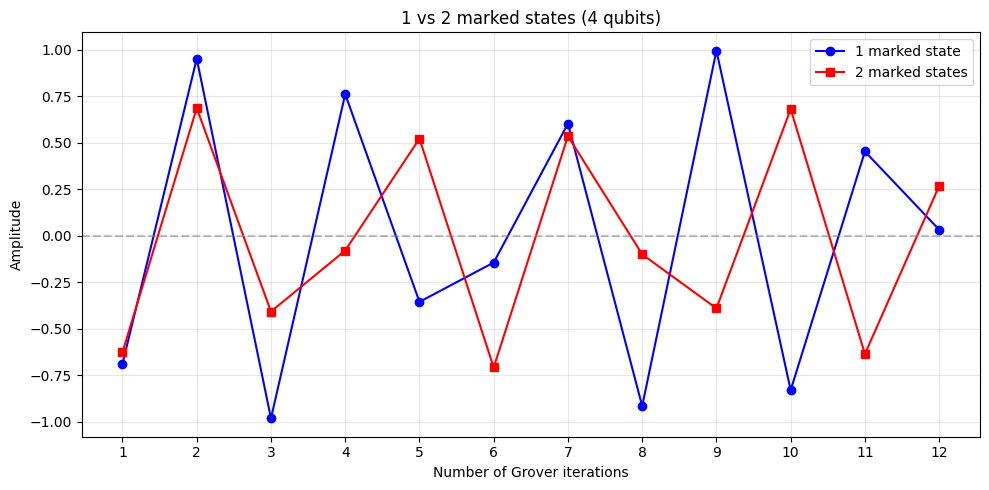

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_iter+1), amps_list, 'bo-', label='1 marked state')
plt.plot(range(1, max_iter+1), amps_list2, 'rs-', label='2 marked states')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Number of Grover iterations')
plt.ylabel('Amplitude')
plt.title('1 vs 2 marked states (4 qubits)')
plt.xticks(range(1, max_iter+1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

With 2 marked states the amplitude starts diminishing earlier, around **iteration 2** instead of 3-4 with 1 state.

This makes sense because the optimal number of iterations is pi/4 * sqrt(N/M) so when theres more solutions (M bigger) we need less iterations. The rotation toward the solution subspace is faster because the projection is larger but we also overshoot faster.

## TODO 7 - Transpilation with limited connectivity

We transpile the circuit to a cycle topology (q0-q1, q1-q2, q2-q3, q3-q0) with only CNOT, Rz, Rx and H gates.

In [15]:
# build the grover circuit, 4 qubits, 3 iterations (close to optimal)
n_qubits = 4
qc_grover = QuantumCircuit(n_qubits)
for q in range(n_qubits):
    qc_grover.h(q)
for i in range(3):
    gen_oracle(qc_grover, ['1010'])
    gen_diffusion(qc_grover)

print(f"Original depth: {qc_grover.depth()}")
print(f"Original gate count: {qc_grover.size()}")

Original depth: 25
Original gate count: 70


In [16]:
# cycle coupling map
coupling = [[0,1],[1,0],[1,2],[2,1],[2,3],[3,2],[3,0],[0,3]]
basis = ['cx', 'rz', 'rx', 'h']

qc_trans = transpile(qc_grover, basis_gates=basis, coupling_map=coupling, optimization_level=3)

print(f"Transpiled depth: {qc_trans.depth()}")
print(f"Transpiled gate count: {qc_trans.size()}")
print(f"Depth increase: {qc_trans.depth() / qc_grover.depth():.1f}x")

Transpiled depth: 345


Transpiled gate count: 512
Depth increase: 13.8x


In [17]:
# count the gate types
counts_gates = {}
for inst in qc_trans.data:
    g = inst.operation.name
    if g in counts_gates:
        counts_gates[g] += 1
    else:
        counts_gates[g] = 1

print("Gate types:")
for g in sorted(counts_gates):
    print(f"  {g}: {counts_gates[g]}")

Gate types:
  cx: 199
  h: 23
  rx: 89
  rz: 201


The depth increases a lot becuase the multi-controlled gates (mcp) are not in the basis gate set so they have to be decomposed into many elementary cx/rz/rx/h gates. Also the cycle topology means that qubits that are not neighbors need SWAP operations wich adds even more gates.

If we consider a noisy simulation, each gate adds some error so a deeper circuit accumulates way more noise. The probability of getting the correct answer decreases exponentialy with the depth.

## TODO 8 - Noisy simulation

We create a Pauli error model for each gate and see how noise afects the output.

In [18]:
def run_noisy(qc_trans, noise_lvl, shots=4096):
    noise_model = NoiseModel()
    
    # 1 qubit error
    p = noise_lvl
    err1 = pauli_error([('X', p/3), ('Y', p/3), ('Z', p/3), ('I', 1-p)])
    
    # 2 qubit error (cx is about 10x noisier)
    p2 = noise_lvl * 10
    if p2 > 1:
        p2 = 0.99
    err2 = pauli_error([
        ('XX', p2/15), ('XY', p2/15), ('XZ', p2/15), ('XI', p2/15),
        ('YX', p2/15), ('YY', p2/15), ('YZ', p2/15), ('YI', p2/15),
        ('ZX', p2/15), ('ZY', p2/15), ('ZZ', p2/15), ('ZI', p2/15),
        ('IX', p2/15), ('IY', p2/15), ('IZ', p2/15),
        ('II', 1-p2)
    ])
    
    noise_model.add_all_qubit_quantum_error(err1, ['h','rx','rz'])
    noise_model.add_all_qubit_quantum_error(err2, ['cx'])
    
    qc_m = qc_trans.copy()
    qc_m.measure_all()
    
    sim = AerSimulator(noise_model=noise_model)
    res = sim.run(qc_m, shots=shots).result()
    return res.get_counts()

noise = 0: P(1010) = 0.9594
noise = 0.001: P(1010) = 0.1782


noise = 0.005: P(1010) = 0.0638


noise = 0.01: P(1010) = 0.0654


noise = 0.02: P(1010) = 0.0626


noise = 0.05: P(1010) = 0.0581


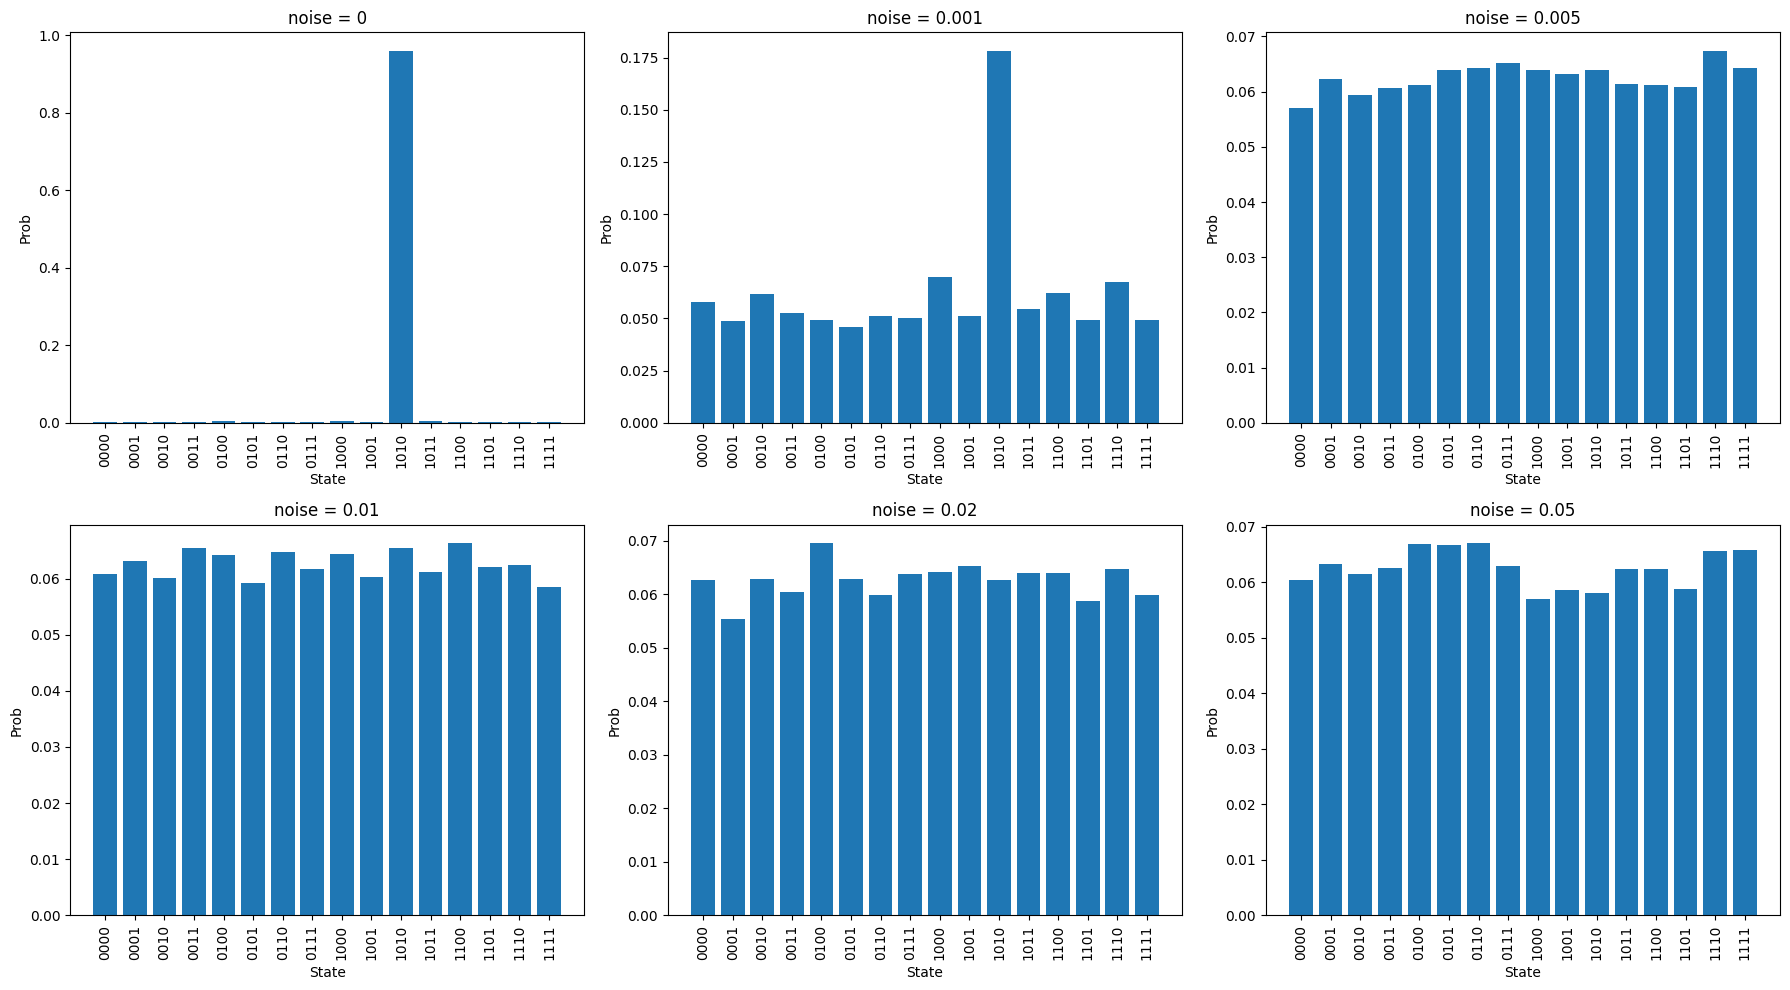

In [19]:
noise_levels = [0, 0.001, 0.005, 0.01, 0.02, 0.05]
shots = 8192

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
probs_marked = []

for i in range(len(noise_levels)):
    noise = noise_levels[i]
    row = i // 3
    col = i % 3
    
    if noise == 0:
        # noiseless run
        qc_m = qc_trans.copy()
        qc_m.measure_all()
        sim = AerSimulator()
        res = sim.run(qc_m, shots=shots).result()
        cnts = res.get_counts()
    else:
        cnts = run_noisy(qc_trans, noise, shots)
    
    # get prob of 1010
    if '1010' in cnts:
        p = cnts['1010'] / shots
    else:
        p = 0
    probs_marked.append(p)
    
    # sort and plot
    keys = sorted(cnts.keys())
    vals = []
    for k in keys:
        vals.append(cnts[k] / shots)
    
    axes[row][col].bar(keys, vals)
    axes[row][col].set_title(f'noise = {noise}')
    axes[row][col].set_xlabel('State')
    axes[row][col].set_ylabel('Prob')
    axes[row][col].tick_params(axis='x', rotation=90)
    
    print(f"noise = {noise}: P(1010) = {p:.4f}")

plt.tight_layout()
plt.show()

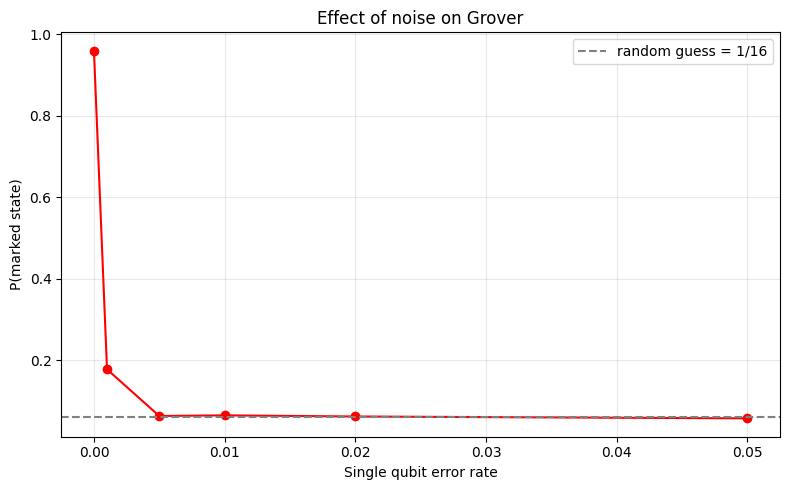

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, probs_marked, 'ro-')
plt.axhline(y=1/16, color='gray', linestyle='--', label='random guess = 1/16')
plt.xlabel('Single qubit error rate')
plt.ylabel('P(marked state)')
plt.title('Effect of noise on Grover')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

When noise increases the probability of the marked state goes down and approaches 1/16 wich is just random guessing.

With an exponential noise model, the fidelity goes like F ~ exp(-lambda * depth). So more iterations means a deeper circuit wich means more noise. At some point adding iterations actualy makes things worse because the noise destroys the coherance faster than the amplification helps. This is why we need quantum error correction for deep circuits like Grover.

## TODO 9 - 40 qubits Grover

We build a 40 qubit Grover circuit with 20 iterations and look at the depth after transpilation. We wont simulate it because our computer would crash.

In [21]:
n_qubits = 40

qc_40 = QuantumCircuit(n_qubits)

for q in range(n_qubits):
    qc_40.h(q)

# 20 grover iterations with a simple oracle (multi controlled phase on |111...1>)
for iteration in range(20):
    # oracle : just a big mcp gate
    ctrl = []
    for i in range(n_qubits - 1):
        ctrl.append(i)
    qc_40.mcp(np.pi, ctrl, n_qubits - 1)
    
    # diffusion
    gen_diffusion(qc_40)

print(f"Original depth: {qc_40.depth()}")
print(f"Original gates: {qc_40.size()}")

Original depth: 121
Original gates: 3280


In [22]:
# 40 qubit cycle coupling map
coupling_40 = []
for i in range(n_qubits):
    j = (i+1) % n_qubits
    coupling_40.append([i, j])
    coupling_40.append([j, i])

basis = ['cx', 'rz', 'rx', 'h']

print("Transpiling... (this takes a while)")
qc_40t = transpile(qc_40, basis_gates=basis, coupling_map=coupling_40, optimization_level=2)

print(f"\nTranspiled depth: {qc_40t.depth()}")
print(f"Transpiled gates: {qc_40t.size()}")

# count gates
gc = {}
for inst in qc_40t.data:
    g = inst.operation.name
    if g in gc:
        gc[g] += 1
    else:
        gc[g] = 1

print("\nGate counts:")
for g in sorted(gc):
    print(f"  {g}: {gc[g]}")

Transpiling... (this takes a while)



Transpiled depth: 2171694


Transpiled gates: 3048412



Gate counts:
  cx: 906624
  h: 22791
  rx: 955038
  rz: 1163959


The transpiled circuit has a depth of over 2 million wich is absolutely enormous.

**Is it reasonnable to run this on a noisy quantum computer without error correction?**

No. With current error rates (about 10^-3 per gate), the fidelity would be F ~ exp(-10^-3 * 10^6) = exp(-1000) wich is basically 0. The output would be pure noise, completly indistinguishable from random. We would absolutly need quantum error correction to run this, wich would require way more physical qubits (hundreds or thousands per logical qubit).